# Jack’s Car Rental — Example 4.2 and Exercise 4.7

State $(s_1,s_2)$ is the number of cars at the end of the day (0–20 at each location). An action $a>0$ moves cars from location 1 to 2; $a<0$ moves cars in the other direction. At most five cars can move; both inventories after moving must remain between 0 and 20. Initial policy: never move a car.

Requests are independent Poisson variables with means $(3,4)$; returns have means $(3,2)$. Each fulfilled rental earns $10, and 
```math
\gamma=0.9
```
Excess demand is lost; excess returned cars are discarded. There are no terminal states.

## Modified costs

After moving, $m_1=s_1-a$ and $m_2=s_2+a$. With m_i = cars in location i after transfer. The following costs are for modified model:

$$c_{\mathrm{move}}(a)=\begin{cases}2\max(a-1,0)&a>0\\2|a|&a\leq0.\end{cases}$$

$$c_{\mathrm{park}}(m_1,m_2)=4\mathbf{1}\{m_1>10\}+4\mathbf{1}\{m_2>10\}.$$


- **MODIFIED MODEL**: **first** car moved from **1 --> 2** is free, while next ones are charged 2$ each, while the opposite (**2 --> 1**) costs always 2$. Parking is charged after moving, before next-day rentals. 
- **ORIGINAL MODEL**: transfer cost always $2|a|$ and no parking charge.

## Bellman update

$T_i[m,n]$ is the probability of end-of-day inventory $n$ given inventory $m$ after moving. Infinite Poisson tails are grouped into events “all cars rented” and “parking capacity reached”, so probability mass is not discarded. Considering 10$ for EACH SATISFIED REQUESTS on both locations, so the poisson variables: 
```math
D_1\sim\operatorname{Poisson}(3),
\qquad
D_2\sim\operatorname{Poisson}(4).
```

we have:

```math
\bar r(s,a)=10\left(\mathbb E[\min(D_1,m_1)]+\mathbb E[\min(D_2,m_2)]\right)-c_{\mathrm{move}}(a)-c_{\mathrm{park}}(m_1,m_2).
```

--> already contains the expected value of r over all possible next states, so the action value function will only contain the average of the state value over different s'.

$$Q_V(s,a)=\bar r(s,a)+\gamma\sum_{n_1,n_2}T_1[m_1,n_1]T_2[m_2,n_2]V(n_1,n_2).$$

Policy evaluation repeatedly updates $V(s)\leftarrow Q_V(s,\pi(s))$ with the policy fixed. Policy improvement chooses $\pi(s)\in\arg\max_a Q_V(s,a)$, keeping the previous action on numerical ties.


In [ ]:
"""Sutton & Barto, Example 4.2 and Exercise 4.7.

Run: python jacks_car_rental.py
Dependencies: numpy scipy matplotlib
State (s1, s2): cars at the end of the day.
Action a > 0: move a cars from location 1 to location 2 overnight.
Requests and returns are independent Poisson variables at both locations.
"""

from pathlib import Path
import json
import numpy as np
from scipy.stats import poisson
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

MAX_CARS = 20
MAX_MOVE = 5
GAMMA = 0.9
RENTAL_REWARD = 10.0
ACTIONS = np.arange(-MAX_MOVE, MAX_MOVE + 1)


def location_model(request_mean, return_mean, capacity=MAX_CARS):
    """T[m,n] = P(end-of-day inventory n | morning inventory m).

    Requests >= m are grouped into the event 'rent all m cars'.
    Returns filling/exceeding capacity are grouped into the last column.
    Thus infinite Poisson tails are included, rather than discarded.
    """
    transition = np.zeros((capacity + 1, capacity + 1)) #filled so that transition[m, n] = P(n | m) meaning the prob. of having 'n' cars at the end of the day given that I had 'm' at the beginning (so it depend on how many I received back from rent and how many I will rent)
    expected_rentals = np.zeros(capacity + 1) #exp. val. of rent cars at the end of the day, given 'm' initially
    for m in range(capacity + 1):
        # E[min(D,m)] = sum_{k=1}^m P(D >= k). --> I rent 'k' cars if D >= k (if I have at least k available cars)
        expected_rentals[m] = poisson.sf( #!sf array of P(D > x) for every x (arange(m)), so we sum these probs for every x from 0 to m (i have m cars) to obtain E[#rents | m]
            np.arange(m), request_mean
        ).sum()
        for rented in range(m + 1): #considering every possible number of rented car (up to m)
            demand_probability = (
                poisson.pmf(rented, request_mean)
                if rented < m #if we have 'rented' requests with 'rented' < m, then to rent 'rented' cars we need EXACTLY 'rented' demands --> single prob density P('rented') computed with `pmf`
                else poisson.sf(m - 1, request_mean) #if I have 'rented' >= m requests, then the prob is the cumsum of the probs of every 'rented' >= m, like before (but here just for one 'x', so single value, no list in sf)
            )
            n = m - rented #how many cars remain in the location

            returned = np.arange(capacity - n) #I have (capacity - n) FREE CAR SPACE in the location, meaning that we can host these cars, as they are returned from prior rents
            #I consider returned = [0, 1, ..., capacity - n - 1] excluding if they return exactly capacity - n or more, since this will be considered in next lines
            #e.g.
            #C = 5, m = 3, rented = 1 --> n = 2 --> returned = [0, 1, 2] excluding >= 3 (we will use sf instead of pmf)
            transition[m, n:capacity] += (
                demand_probability * poisson.pmf(returned, return_mean)
            )
            # the probability transition[m, n] is the probability to have `n` cars starting with `m` and having rented `n` --> it means tha NO CAR was returned, so:
            # transition[m, n] = P(rented = 1) * P(returned = 0)
            # transition[m, n + 1] = P(rented = 1) * P(returned = 1) ecc... until transition[m, capacty - 1] so transition[3, 4]


            transition[m, capacity] += demand_probability * poisson.sf(
                capacity - n - 1, return_mean
            )
            #same as before but here we consider the cumsum of probs P[returned >= (capacity - n)] since they saturate to capacity - n (but we still consider them instead of cutting, as before when we used sf)
    return transition, expected_rentals


def transfer_cost(action, modified=False):
    if modified and action > 0:
        return 2.0 * (action - 1)
    return 2.0 * abs(action)


class CarRental:
    def __init__(self, modified=False, capacity=MAX_CARS):
        self.modified = modified
        self.capacity = capacity
        self.t1, rentals1 = location_model(3, 3, capacity)
        self.t2, rentals2 = location_model(4, 2, capacity)
        self.s1, self.s2 = np.indices((capacity + 1, capacity + 1))
        self.m1 = self.s1[None, :, :] - ACTIONS[:, None, None]
            #(1, MAX_CARS, MAX_CARS)  - (11, 1, 1) --> (11, 21, 21)
        self.m2 = self.s2[None, :, :] + ACTIONS[:, None, None]
        # A transfer must leave both inventories in [0, capacity].
        self.feasible = (
            (self.m1 >= 0) & (self.m1 <= capacity)
            & (self.m2 >= 0) & (self.m2 <= capacity)
        )
        # Safe indices for vectorized calculations; invalid actions are masked.
        self.m1 = np.clip(self.m1, 0, capacity)
        self.m2 = np.clip(self.m2, 0, capacity)
        self.reward = RENTAL_REWARD * (
            rentals1[self.m1] + rentals2[self.m2]
        ) #(11, 21, 21)
        self.reward -= np.array([
            transfer_cost(int(a), modified) for a in ACTIONS
        ])[:, None, None] #transfer_cost functions return (ACTIONS,) array, then [:, None, None] trnsforms it to (ACTIONS, 1, 1) to make substraction with reward: (11, 21, 21) obtaining still (11, 21, 21)
        if modified:
            self.reward -= 4.0 * (
                (self.m1 > 10).astype(float) + (self.m2 > 10).astype(float)
            )

    def action_values(self, values):
        # E[m1,m2] = sum_{n1,n2} T1[m1,n1] T2[m2,n2] V[n1,n2].
        expectation = self.t1 @ values @ self.t2.T
        q = self.reward + GAMMA * expectation[self.m1, self.m2]
#       expectation.shape                    # (21, 21)
#       expectation[self.m1, self.m2].shape    # (11, 21, 21)
        return np.where(self.feasible, q, -np.inf)


def evaluate_policy(model, policy, values, tolerance=1e-10):
    """Iterative policy evaluation, with the policy held fixed."""
    indices = policy + MAX_MOVE 
    #actions = [-5, -4, -3, ..., 5] --> actions + 5 = [0, 1, 2, 3, ..., 10] --> applied over all states in policy: (21, 21) maintaining its size --> for each state (s1, s2) I map the action (e.g. -3) to its index in the ACTIONS array (e.g. 2)
    for sweep in range(1, 10001):
        q = model.action_values(values)
        new_values = q[indices, model.s1, model.s2]
        delta = np.max(np.abs(new_values - values))
        values = new_values
        if delta < tolerance:
            return values, sweep
    raise RuntimeError("Policy evaluation did not converge")


def policy_iteration(model, tolerance=1e-10):
    """Start with pi_0(s)=0, as in Figure 4.2; retain old actions on ties."""
    policy = np.zeros((model.capacity + 1, model.capacity + 1), dtype=int)
    values = np.zeros_like(policy, dtype=float)
    history = [policy.copy()]
    for iteration in range(1, 101):
        values, sweeps = evaluate_policy(model, policy, values, tolerance)
        q = model.action_values(values)
        maximum = q.max(axis=0) #(21, 21) --> best a for each state (s1, s2)
        old_q = q[policy + MAX_MOVE, model.s1, model.s2]
        best_policy = ACTIONS[q.argmax(axis=0)] #ACTIONS[(21, 21)] since argmax finds the index of the action that maximizes q for each (s1, s2)
        #this substitues each index in (21, 21) with ACTIONS[i]

        #e.g.
        # ACTIONS = np.array([-1, 0, 1])

        # indices = np.array([
        #     [0, 2],
        #     [1, 0]
        # ])

        #ACTIONS[indices]

        # ---> array([
        #         [-1,  1],  # ACTIONS[0], ACTIONS[2]
        #         [ 0, -1]   # ACTIONS[1], ACTIONS[0]
        #     ])

        
        # Only change an action when a strictly better one exists.
        keep_old = np.isclose(old_q, maximum, rtol=0, atol=1e-9)
        new_policy = np.where(keep_old, policy, best_policy)
        changed = int(np.count_nonzero(new_policy != policy))
        print(f"iteration {iteration}: evaluation sweeps={sweeps}, "
              f"changed states={changed}")
        if changed == 0:
            residual = float(np.max(np.abs(maximum - values)))
            return values, policy, history, residual
        policy = new_policy
        history.append(policy.copy())
    raise RuntimeError("Policy iteration did not stabilize")


def value_iteration(model, tolerance=1e-10):
    """Independent optimality iteration to check policy-iteration results."""
    values = np.zeros((model.capacity + 1, model.capacity + 1))
    for _ in range(10001):
        new_values = model.action_values(values).max(axis=0)
        if np.max(np.abs(new_values - values)) < tolerance:
            return new_values
        values = new_values
    raise RuntimeError("Value iteration did not converge")


def check_model(model):
    for transition in (model.t1, model.t2):
        assert np.all(transition >= 0)
        np.testing.assert_allclose(transition.sum(axis=1), 1, atol=1e-12)
    # With no morning cars, the final inventory is capped Poisson returns.
    n = model.capacity
    expected = np.r_[poisson.pmf(np.arange(n), 3), poisson.sf(n - 1, 3)]
    np.testing.assert_allclose(model.t1[0], expected, atol=1e-12)
    assert transfer_cost(1, True) == 0
    assert transfer_cost(2, True) == 2
    assert transfer_cost(-1, True) == 2
    # Exactly 10 cars incur no parking charge; 11 incur $4 per location.
    original = CarRental(False, model.capacity)
    modified = CarRental(True, model.capacity)
    zero = MAX_MOVE
    assert original.reward[zero, 10, 10] == modified.reward[zero, 10, 10]
    np.testing.assert_allclose(
        original.reward[zero, 11, 11] - modified.reward[zero, 11, 11], 8
    )


def draw_policy(ax, policy, title):
    cmap = plt.get_cmap("RdBu_r", len(ACTIONS))
    norm = BoundaryNorm(np.arange(-5.5, 6.5), cmap.N)
    im = ax.imshow(policy, origin="lower", extent=(-.5, 20.5, -.5, 20.5),
                   cmap=cmap, norm=norm, interpolation="nearest")
    for s1 in range(21):
        for s2 in range(21):
            a = int(policy[s1, s2])
            color = "white" if abs(a) >= 4 else "black"
            ax.text(s2, s1, str(a), ha="center", va="center", fontsize=5.5,
                    color=color)
    ax.set(title=title, xlabel="Cars at location 2", ylabel="Cars at location 1")
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_yticks([0, 5, 10, 15, 20])
    return im


def main(output_dir=None):
    output = Path(output_dir) if output_dir else Path(__file__).resolve().parent
    output.mkdir(parents=True, exist_ok=True)
    results = {}
    summary = {}
    for name, modified in (("original", False), ("modified", True)):
        print(f"\n{name.upper()}")
        model = CarRental(modified)
        check_model(model)
        values, policy, history, residual = policy_iteration(model)
        reference = value_iteration(model)
        difference = float(np.max(np.abs(values - reference)))
        assert difference < 1e-7
        assert residual < 1e-8
        assert np.all(model.feasible[policy + MAX_MOVE, model.s1, model.s2])
        results[name] = (values, policy, history)
        summary[name] = {
            "policy_improvements": len(history) - 1,
            "bellman_optimality_residual": residual,
            "max_difference_from_value_iteration": difference,
            "V_0_0": float(values[0, 0]),
            "V_20_20": float(values[20, 20]),
            "policy_action_counts": {
                str(int(a)): int(np.count_nonzero(policy == a)) for a in ACTIONS
            },
        }
        np.savez(output / f"{name}_results.npz", V=values, policy=policy,
                 policy_history=np.stack(history))
    print(json.dumps(summary, indent=2))
    (output / "validation.json").write_text(json.dumps(summary, indent=2) + "\n")

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
    for ax, name in zip(axes, ("original", "modified")):
        im = draw_policy(ax, results[name][1], f"Optimal policy: {name}")
    fig.colorbar(im, ax=axes, ticks=ACTIONS, shrink=.8,
                 label="Cars moved: positive = location 1 to location 2")
    fig.savefig(output / "optimal_policies.png", dpi=200)
    plt.close(fig)

    history = results["original"][2]
    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
    for i, policy in enumerate(history):
        draw_policy(axes.flat[i], policy, f"Original: policy {i}")
    for ax in axes.flat[len(history):]:
        ax.set_visible(False)

    # The sixth panel of Figure 4.2 is the final state-value function.
    axes.flat[5].remove()
    surface = fig.add_subplot(2, 3, 6, projection="3d")
    s1, s2 = np.indices((21, 21))
    surface.plot_surface(s2, s1, results["original"][0], cmap="viridis",
                         linewidth=0.2, edgecolor="black", alpha=.9)
    surface.set(title="Original: optimal state values",
                xlabel="Cars at location 2", ylabel="Cars at location 1",
                zlabel="Expected discounted return")
    fig.savefig(output / "original_policy_iteration.png", dpi=180)
    plt.close(fig)



    history = results["modified"][2]
    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
    for i, policy in enumerate(history):
        draw_policy(axes.flat[i], policy, f"Modified: policy {i}")
    for ax in axes.flat[len(history):]:
        ax.set_visible(False)
        
    axes.flat[5].remove()

    surface = fig.add_subplot(2, 3, 5, projection="3d")
    s1, s2 = np.indices((21, 21))
    surface.plot_surface(s2, s1, results["modified"][0], cmap="viridis",
                         linewidth=0.2, edgecolor="black", alpha=.9)
    surface.set(title="Modified: optimal state values",
                xlabel="Cars at location 2", ylabel="Cars at location 1",
                zlabel="Expected discounted return")
    fig.savefig(output / "modified_policy_iteration.png", dpi=180)
    plt.close(fig)
    return results



## Solve and validate

The program checks stochastic transition rows, transfer direction, parking thresholds, feasible actions and agreement with value iteration. Figures below show the verified results; rerunning writes updated figures into `jacks_car_rental_output`.

In [12]:
results = main("jacks_car_rental_output")


ORIGINAL
iteration 1: evaluation sweeps=257, changed states=318
iteration 2: evaluation sweeps=223, changed states=272
iteration 3: evaluation sweeps=211, changed states=79
iteration 4: evaluation sweeps=176, changed states=8
iteration 5: evaluation sweeps=103, changed states=0

MODIFIED
iteration 1: evaluation sweeps=256, changed states=371
iteration 2: evaluation sweeps=230, changed states=265
iteration 3: evaluation sweeps=215, changed states=102
iteration 4: evaluation sweeps=183, changed states=0
{
  "original": {
    "policy_improvements": 4,
    "bellman_optimality_residual": 8.265033102361485e-11,
    "max_difference_from_value_iteration": 2.432898327242583e-11,
    "V_0_0": 421.41406339569033,
    "V_20_20": 636.989606803545,
    "policy_action_counts": {
      "-5": 0,
      "-4": 3,
      "-3": 9,
      "-2": 14,
      "-1": 17,
      "0": 270,
      "1": 33,
      "2": 29,
      "3": 23,
      "4": 17,
      "5": 26
    }
  },
  "modified": {
    "policy_improvements": 3,


## Optimal policies: original and modified

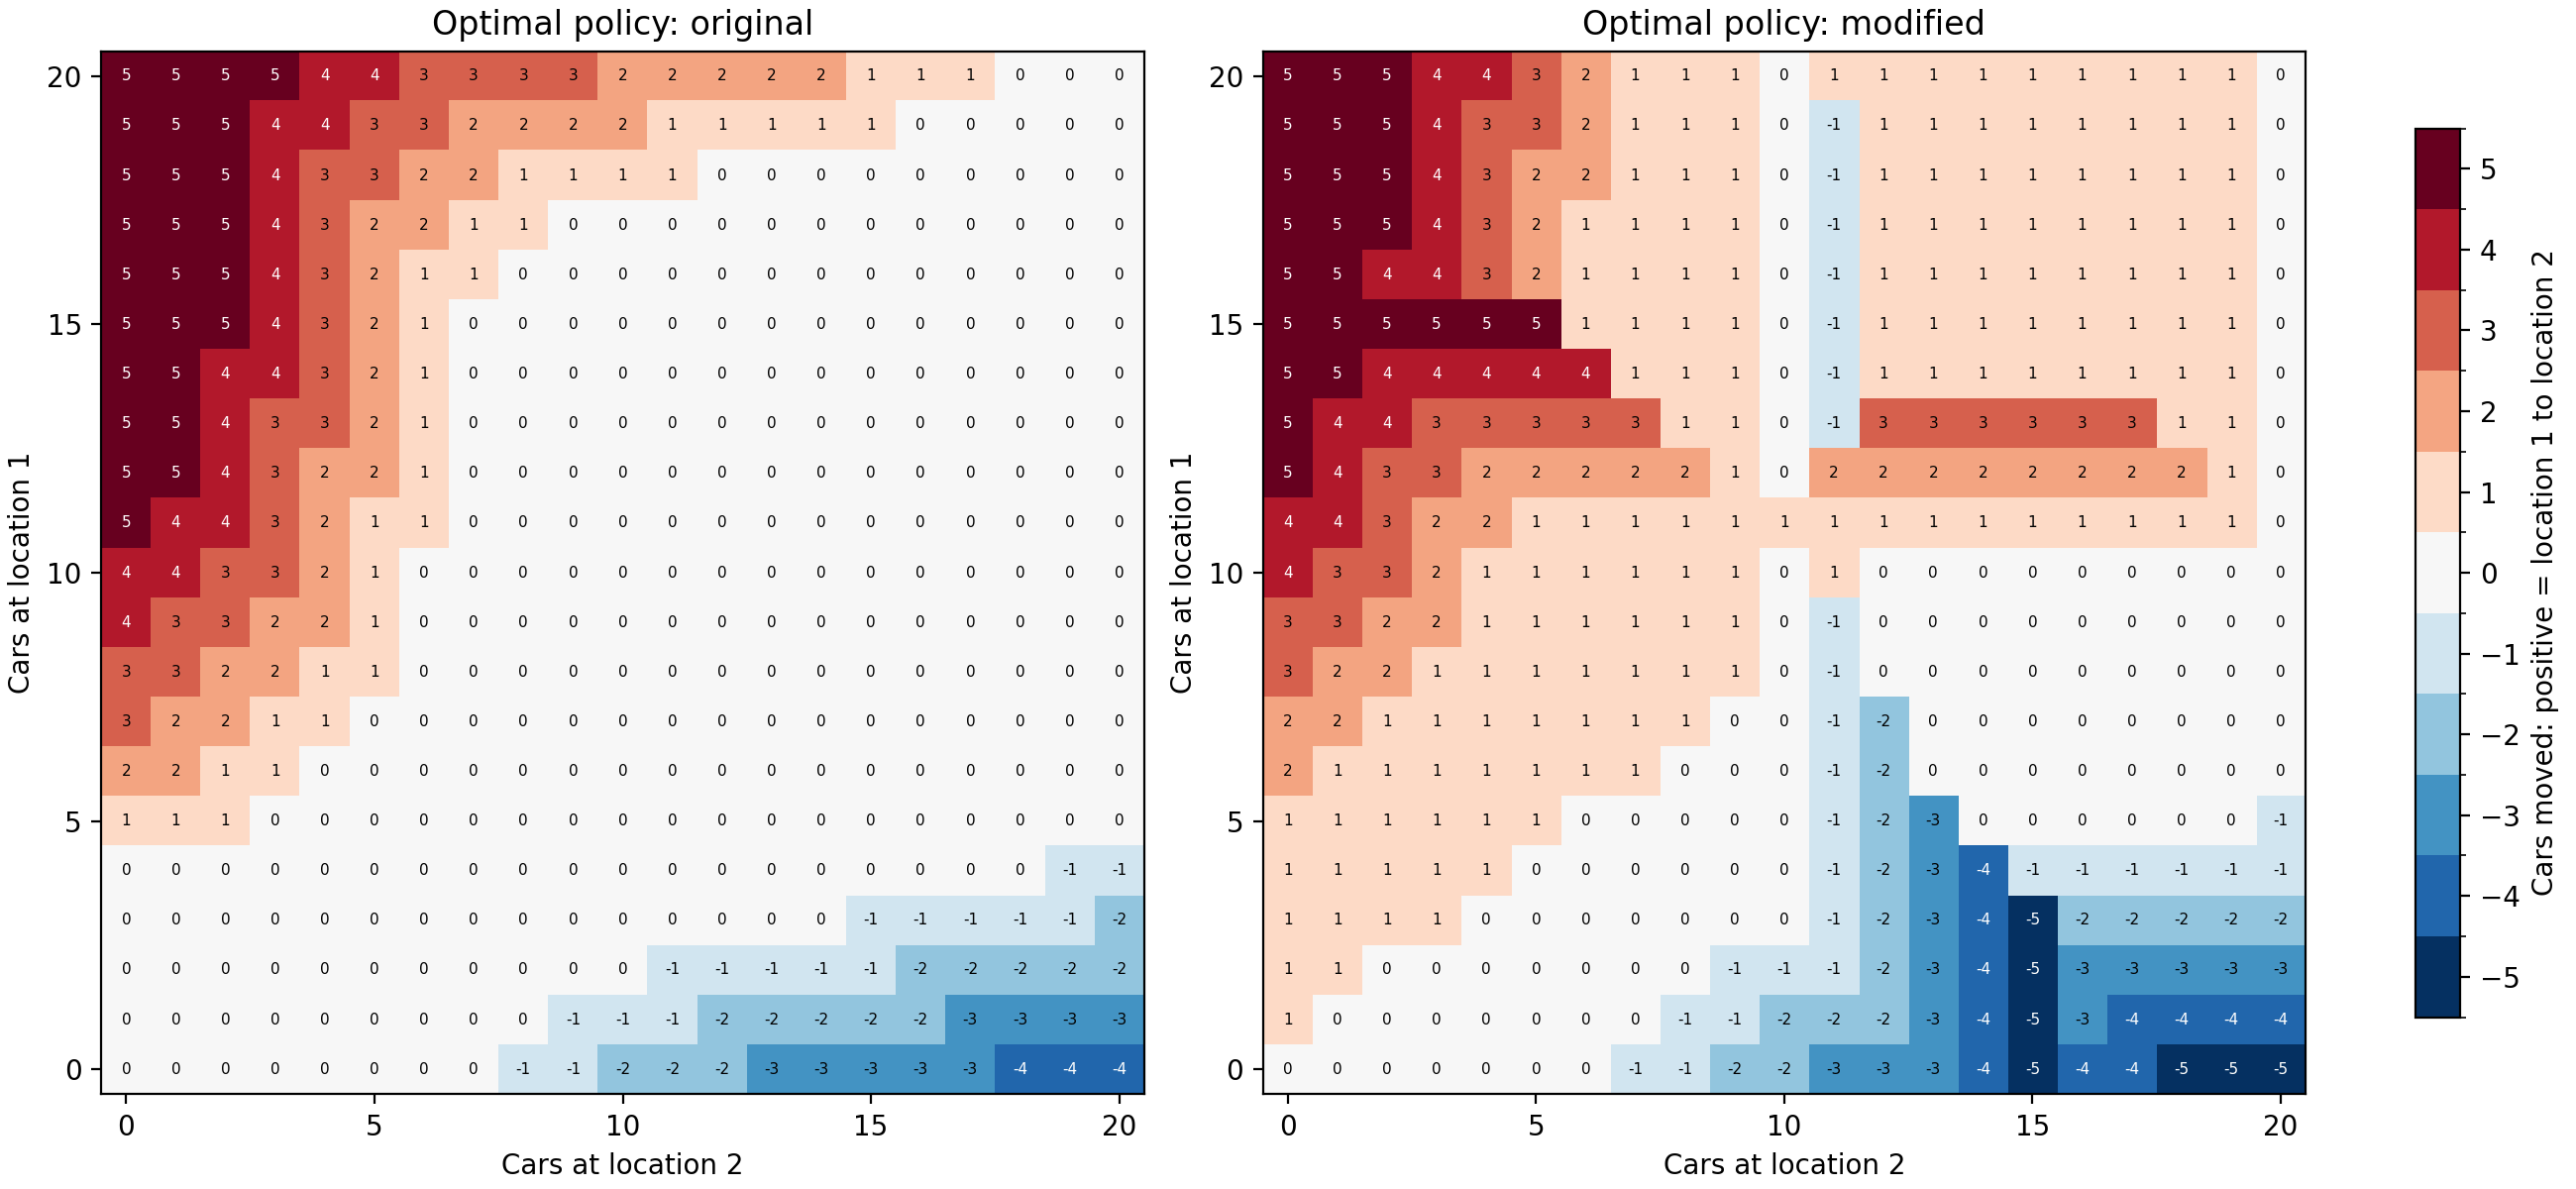

## Original policy iteration and final state values

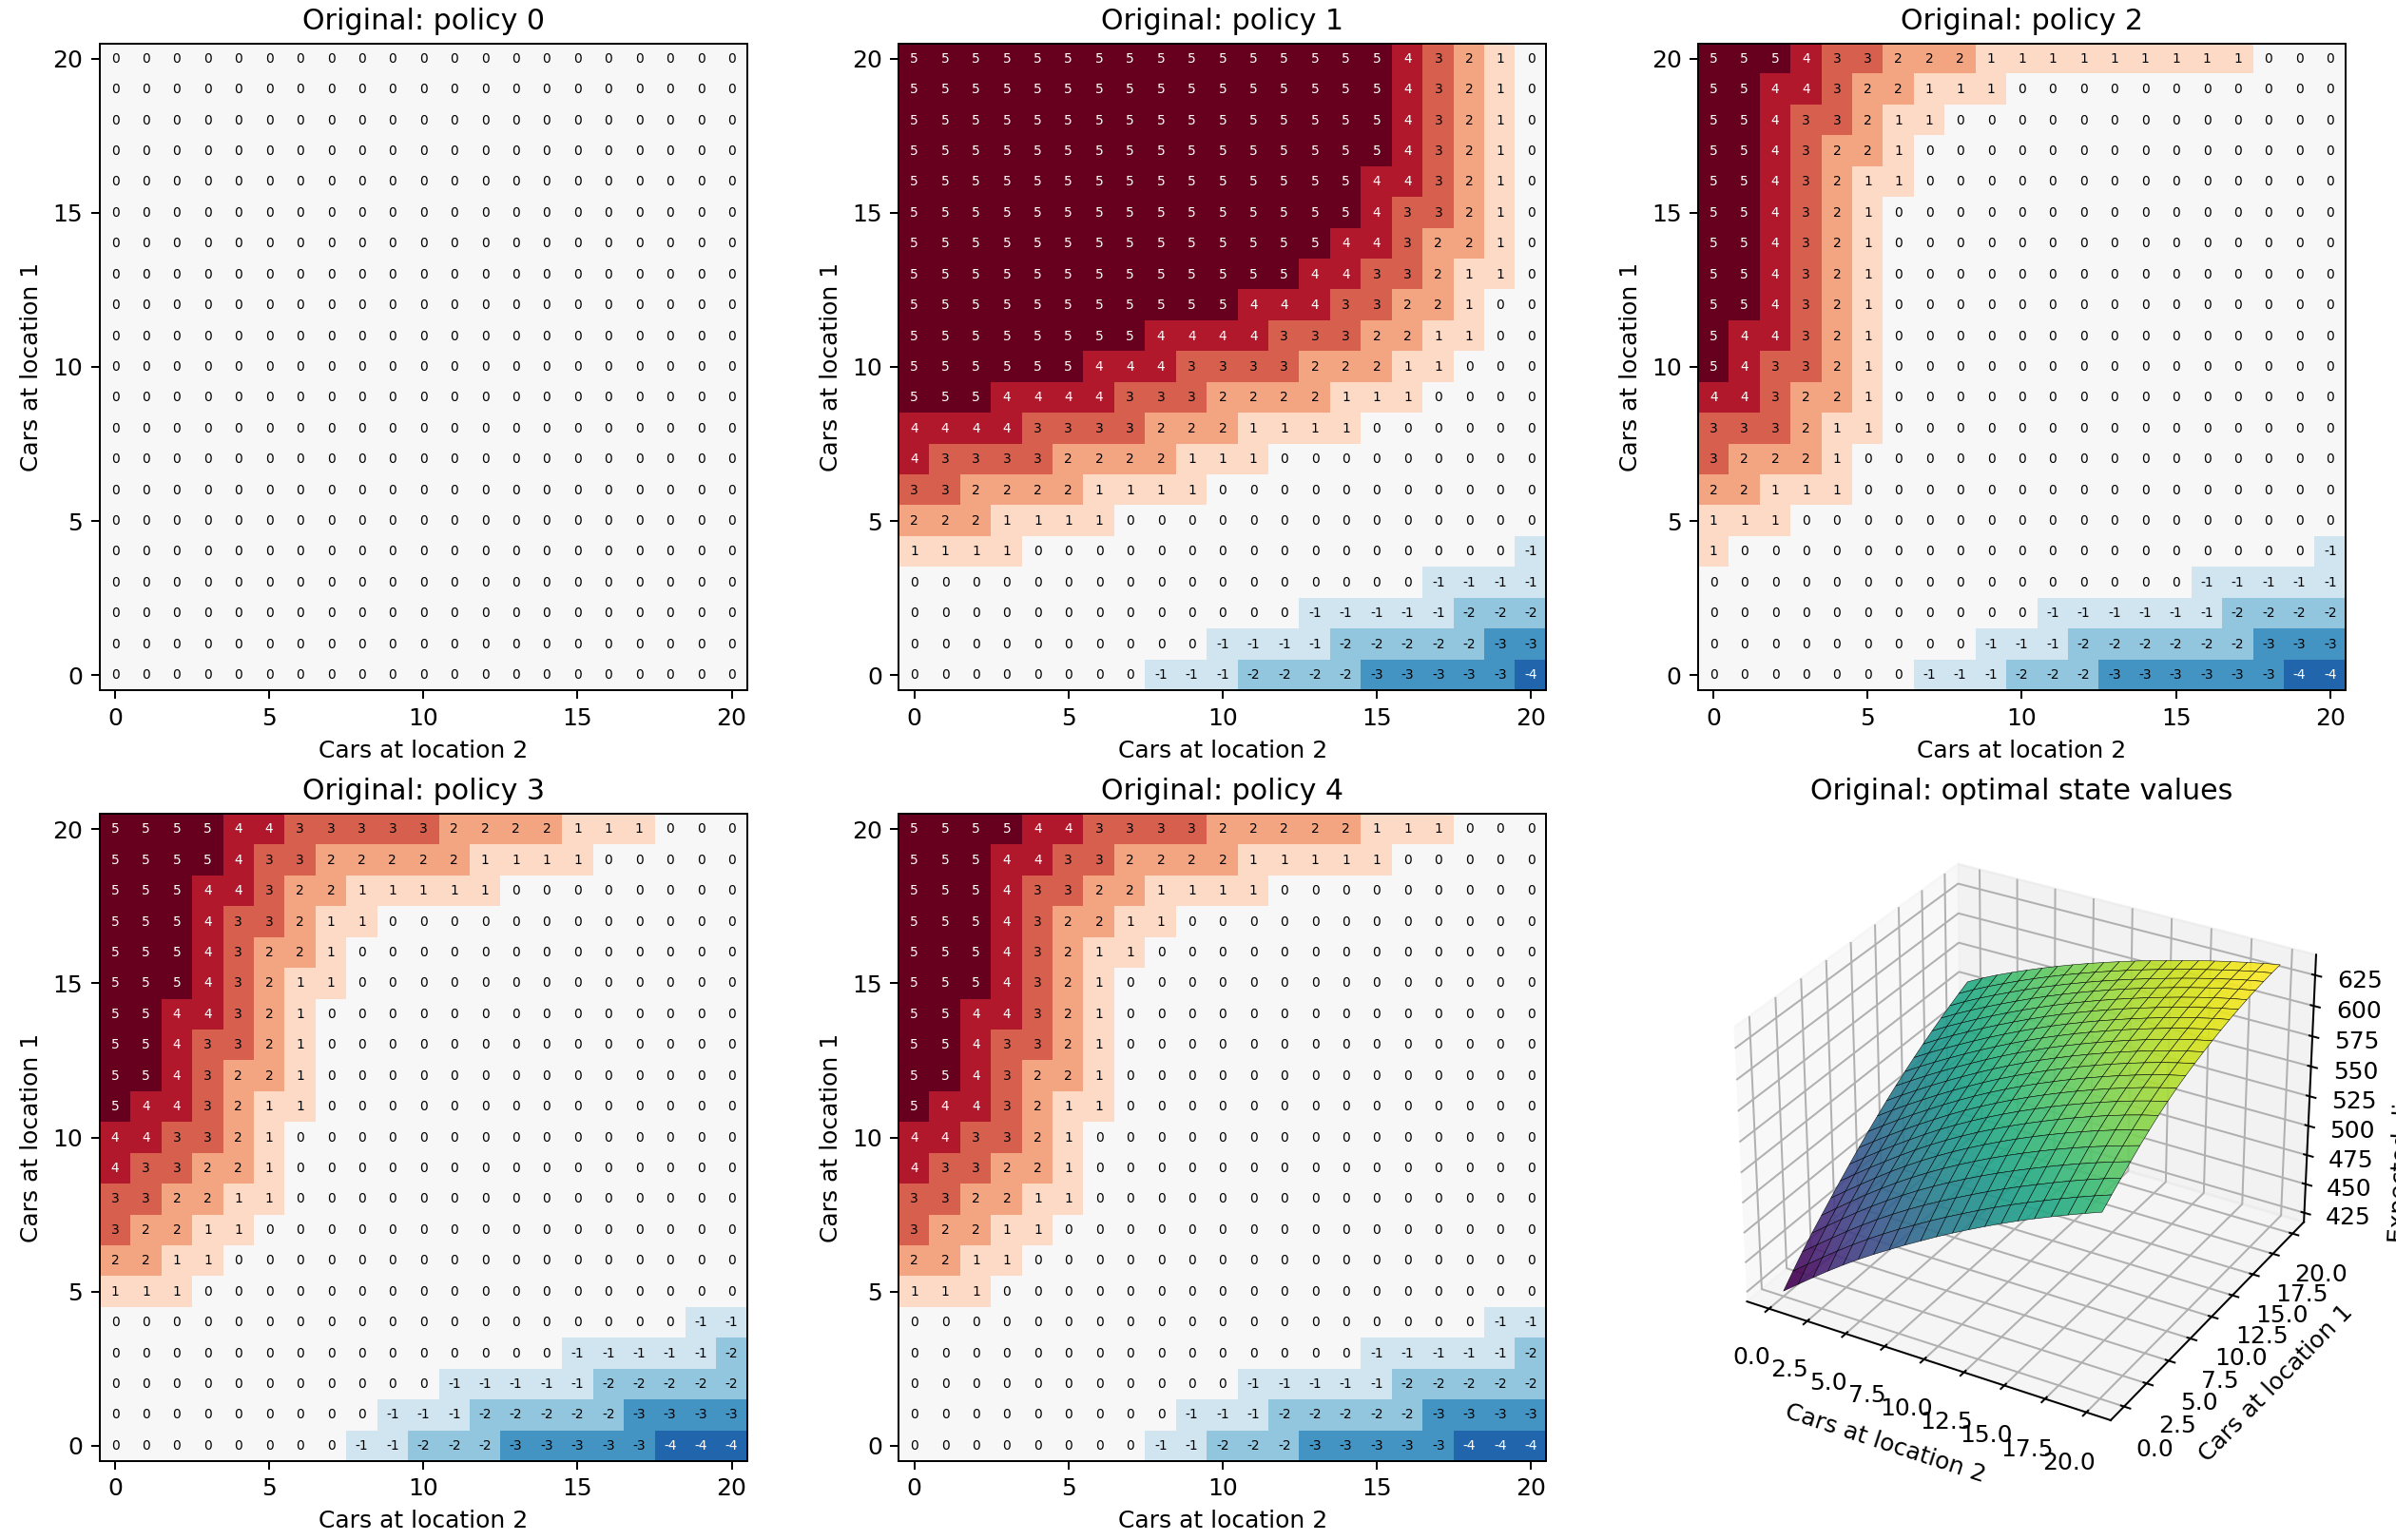

## Modified policy iteration and final state values

![Modified policy iteration and final state values](jacks_car_rental_output/modified_policy_iteration.png)